In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


      EXCELSOFT TECHNOLOGIES: FULL VALUATION AUDIT TRAIL

[PHASE 1: NET WORKING CAPITAL VARIABLES]
Inventory (2025 / 2024):         0.0 / 0.0
Receivables (2025 / 2024):       511.12 / 467.77
Payables (2025 / 2024):          288.53 / 288.05
Net Working Capital 2025:        ₹222.59 Cr
Net Working Capital 2024:        ₹179.72 Cr
CHANGE IN NET WORKING CAPITAL:   ₹42.87 Cr

[PHASE 2: PROVISIONS VARIABLES]
Pension (2025 / 2024):           0.0 / 0.0
Other Provisions (2025 / 2024):  265.89 / 279.11
Specific Provision (2025 / 2024):39.76 / 36.41
Total Provisions 2025:           ₹305.65 Cr
Total Provisions 2024:           ₹315.52 Cr
CHANGE IN TOTAL PROVISIONS:      ₹-9.87 Cr

[PHASE 3: VALUATION & COST OF CAPITAL]
Average Unlevered Beta:          0.449
Final Levered Beta:              0.466
Cost of Equity (Re):             13.06%
Weighted Avg Cost of Cap (WACC): 13.23%
Earnings Before Int & Tax (EBIT):₹542.51 Cr
Net Operating Profit (NOPAT):    ₹406.88 Cr
FREE CASH FLOW TO FIRM (FCFF):   ₹312.7

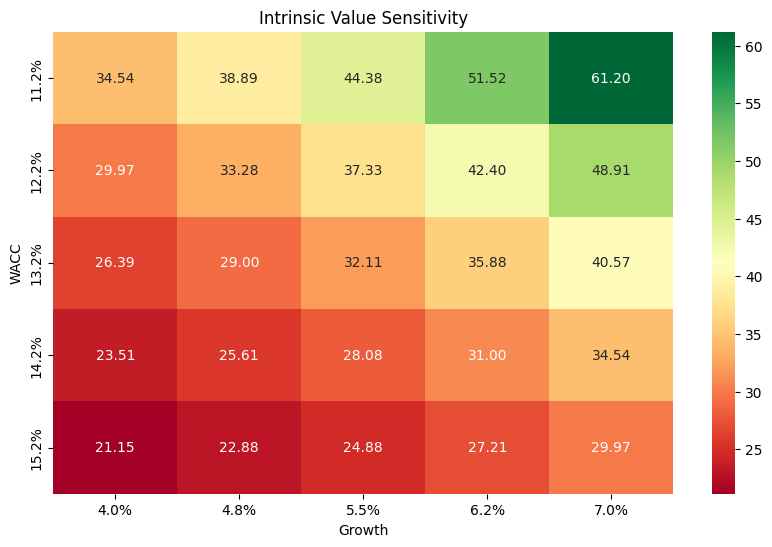

In [ ]:
# ==========================================================
# 1. CLASS: BETA_CALCULATOR
# ==========================================================
class BetaCalculator:
    def __init__(self, peer_data_list, target_debt_to_equity, corporate_tax_rate):
        self.corporate_tax_rate = corporate_tax_rate
        self.target_debt_to_equity = target_debt_to_equity
        self.unlevered_betas = []
        
        for peer in peer_data_list:
            unlevered_calculation = peer['levered_beta'] / (1 + (1 - self.corporate_tax_rate) * peer['debt_to_equity_ratio'])
            if unlevered_calculation > 0:
                self.unlevered_betas.append(unlevered_calculation)

        self.average_unlevered_beta = np.mean(self.unlevered_betas)
        self.final_levered_beta = self.average_unlevered_beta * (1 + (1 - self.corporate_tax_rate) * self.target_debt_to_equity)

# ==========================================================
# 2. CLASS: OPERATING_CASH_FLOW_MANAGER
# ==========================================================
class OperatingCashFlowManager:
    def __init__(self):
        # HARD-CODED DATA FOR AUDIT
        self.inventory_2025, self.inventory_2024 = 0.0, 0.0
        self.receivables_2025, self.receivables_2024 = 511.12, 467.77
        self.payables_2025, self.payables_2024 = 288.53, 288.05
        
        self.net_working_capital_2025 = (self.inventory_2025 + self.receivables_2025) - self.payables_2025
        self.net_working_capital_2024 = (self.inventory_2024 + self.receivables_2024) - self.payables_2024
        self.change_in_net_working_capital = self.net_working_capital_2025 - self.net_working_capital_2024
        
        self.pension_2025, self.pension_2024 = 0.0, 0.0
        self.other_provisions_2025, self.other_provisions_2024 = 265.89, 279.11
        self.specific_provision_2025, self.specific_provision_2024 = 39.76, 36.41
        
        self.total_provisions_2025 = self.pension_2025 + self.other_provisions_2025 + self.specific_provision_2025
        self.total_provisions_2024 = self.pension_2024 + self.other_provisions_2024 + self.specific_provision_2024
        self.change_in_total_provisions = self.total_provisions_2025 - self.total_provisions_2024

# ==========================================================
# 3. CLASS: VALUATION_ENGINE
# ==========================================================
class ValuationEngine:
    def __init__(self, market_data, financial_data, beta_object, cash_flow_object):
        self.market = market_data
        self.financial = financial_data
        self.beta_value = beta_object.final_levered_beta
        self.cf_adj = cash_flow_object

        # Metrics for Audit
        self.cost_of_equity = self.market['risk_free_rate'] + self.beta_value * (self.market['market_risk_premium'] - self.market['risk_free_rate'])
        
        total_v = self.financial['market_value_of_equity'] + self.financial['market_value_of_debt']
        self.wacc = ((self.financial['market_value_of_equity'] / total_v) * self.cost_of_equity) + \
                    ((self.financial['market_value_of_debt'] / total_v) * self.market['pre_tax_cost_of_debt'] * (1 - self.market['corporate_tax_rate']))
        
        self.ebit = self.financial['revenue'] - self.financial['operating_costs'] - self.financial['depreciation_and_amortization']
        self.nopat = self.ebit * (1 - self.market['corporate_tax_rate'])
        
        self.free_cash_flow_to_firm = (
            self.nopat + 
            self.financial['depreciation_and_amortization'] + 
            self.cf_adj.change_in_total_provisions - 
            self.cf_adj.change_in_net_working_capital - 
            self.financial['capital_expenditure']
        )

    def calculate_intrinsic_value(self, g=None, w=None):
        g = g if g is not None else self.financial['terminal_growth_rate']
        w = w if w is not None else self.wacc
        if g >= w: return np.nan
        tv = (self.free_cash_flow_to_firm * (1 + g)) / (w - g)
        ev = (self.free_cash_flow_to_firm / (1 + w)) + (tv / (1 + w))
        return (ev - self.financial['net_debt']) / self.financial['shares_outstanding']

# ==========================================================
# 4. DATA SETUP & FULL VARIABLE PRINTING
# ==========================================================
peers = [
    {'name': 'MPS Ltd', 'levered_beta': 0.54, 'debt_to_equity_ratio': 0.0206},
    {'name': 'Ksolves India Limited', 'levered_beta': 1.03, 'debt_to_equity_ratio': 0.0753},
    {'name': 'Silver Touch Technologies Ltd', 'levered_beta': 0.78, 'debt_to_equity_ratio': 0.2340},
    {'name': 'Sasken Technologies Ltd', 'levered_beta': 0.85, 'debt_to_equity_ratio': 0.0320},
    {'name': 'InfoBeans Technologies Ltd', 'levered_beta': 0.92, 'debt_to_equity_ratio': 0.0410},
    {'name': 'Zensar Technologies Limited', 'levered_beta': 1.15, 'debt_to_equity_ratio': 0.0285},
    {'name': 'Sonata Software Limited', 'levered_beta': 1.21, 'debt_to_equity_ratio': 0.4210},
    {'name': 'Happiest Minds Technologies', 'levered_beta': 1.08, 'debt_to_equity_ratio': 0.2830},
    {'name': 'Coforge Limited', 'levered_beta': 1.32, 'debt_to_equity_ratio': 0.1120},
    {'name': 'Affle India', 'levered_beta': 0.32, 'debt_to_equity_ratio': 0.0118},
    {'name': 'Newgen Software', 'levered_beta': 0.51, 'debt_to_equity_ratio': 0.0325}
]

market_params = {'risk_free_rate': 0.065, 'market_risk_premium': 0.135, 'pre_tax_cost_of_debt': 0.261, 'corporate_tax_rate': 0.25}

excelsoft_fin = {
    'revenue': 2488.0, 'operating_costs': 1846.85, 'depreciation_and_amortization': 98.64, 
    'capital_expenditure': 140.07, 'market_value_of_equity': 13810.10, 
    'market_value_of_debt': 378.16, 'net_debt': 351.3,
    'shares_outstanding': 115.08, 'terminal_growth_rate': 0.06
}

beta_mod = BetaCalculator(peers, 0.05, 0.25)
cf_mod = OperatingCashFlowManager()
engine = ValuationEngine(market_params, excelsoft_fin, beta_mod, cf_mod)

# --- COMPLETE VARIABLE PRINTING ---
print(f"\n{'='*65}")
print(f"      EXCELSOFT TECHNOLOGIES: FULL VALUATION AUDIT TRAIL")
print(f"{'='*65}")

print(f"\n[PHASE 1: NET WORKING CAPITAL VARIABLES]")
print(f"Inventory (2025 / 2024):         {cf_mod.inventory_2025} / {cf_mod.inventory_2024}")
print(f"Receivables (2025 / 2024):       {cf_mod.receivables_2025} / {cf_mod.receivables_2024}")
print(f"Payables (2025 / 2024):          {cf_mod.payables_2025} / {cf_mod.payables_2024}")
print(f"Net Working Capital 2025:        ₹{cf_mod.net_working_capital_2025:.2f} Cr")
print(f"Net Working Capital 2024:        ₹{cf_mod.net_working_capital_2024:.2f} Cr")
print(f"CHANGE IN NET WORKING CAPITAL:   ₹{cf_mod.change_in_net_working_capital:.2f} Cr")

print(f"\n[PHASE 2: PROVISIONS VARIABLES]")
print(f"Pension (2025 / 2024):           {cf_mod.pension_2025} / {cf_mod.pension_2024}")
print(f"Other Provisions (2025 / 2024):  {cf_mod.other_provisions_2025} / {cf_mod.other_provisions_2024}")
print(f"Specific Provision (2025 / 2024):{cf_mod.specific_provision_2025} / {cf_mod.specific_provision_2024}")
print(f"Total Provisions 2025:           ₹{cf_mod.total_provisions_2025:.2f} Cr")
print(f"Total Provisions 2024:           ₹{cf_mod.total_provisions_2024:.2f} Cr")
print(f"CHANGE IN TOTAL PROVISIONS:      ₹{cf_mod.change_in_total_provisions:.2f} Cr")

print(f"\n[PHASE 3: VALUATION & COST OF CAPITAL]")
print(f"Average Unlevered Beta:          {beta_mod.average_unlevered_beta:.3f}")
print(f"Final Levered Beta:              {beta_mod.final_levered_beta:.3f}")
print(f"Cost of Equity (Re):             {engine.cost_of_equity*100:.2f}%")
print(f"Weighted Avg Cost of Cap (WACC): {engine.wacc*100:.2f}%")
print(f"Earnings Before Int & Tax (EBIT):₹{engine.ebit:.2f} Cr")
print(f"Net Operating Profit (NOPAT):    ₹{engine.nopat:.2f} Cr")
print(f"FREE CASH FLOW TO FIRM (FCFF):   ₹{engine.free_cash_flow_to_firm:.2f} Cr")

print(f"\n[PHASE 4: FINAL RESULTS]")
print(f"INTRINSIC VALUE PER SHARE:       ₹{engine.calculate_intrinsic_value():.2f}")
print(f"OFFER PRICE:                     ₹120.00")
print(f"{'='*65}")

# HEATMAP
growth_range = np.linspace(0.04, 0.07, 5)
wacc_swings = np.linspace(engine.wacc - 0.02, engine.wacc + 0.02, 5)
h_data = [[engine.calculate_intrinsic_value(g, w) for g in growth_range] for w in wacc_swings]
plt.figure(figsize=(10, 6)); sns.heatmap(h_data, annot=True, fmt=".2f", cmap="RdYlGn", 
xticklabels=[f"{x*100:.1f}%" for x in growth_range], yticklabels=[f"{x*100:.1f}%" for x in wacc_swings])
plt.title("Intrinsic Value Sensitivity"); plt.xlabel("Growth"); plt.ylabel("WACC"); plt.show()